# 01 — Dataset exploration

A tour of the Batik-plays-Mozart corpus: match files, CC64 pedal signal, and musicological annotations.

In [ ]:
import sys, os
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import partitura as pt, warnings
warnings.filterwarnings('ignore')
from layers import build_score_to_perf_map, build_beat_grid, beat_unit_from_timesig_str

DATASET  = 'path to Batik-plays-Mozart dataset directory (https://github.com/huispaty/batik_plays_mozart)'
MOVEMENT = 'kv279_1'

## Corpus overview

In [2]:
movements = sorted([f.replace('.match','') for f in os.listdir(f'{DATASET}/match')
                    if f.endswith('.match') and not f.startswith('.')])
sonatas = sorted(set(m.rsplit('_',1)[0] for m in movements))
print(f'{len(movements)} movements across {len(sonatas)} sonatas')
print('Sonatas:', ', '.join(sonatas))

36 movements across 12 sonatas
Sonatas: kv279, kv280, kv281, kv282, kv283, kv284, kv330, kv331, kv332, kv333, kv457, kv533


## Load one match file

In [3]:
perf, alignment, score = pt.load_match(
    f'{DATASET}/match/{MOVEMENT}.match', create_score=True)
sna = score.note_array()
pna = perf.note_array()
pp  = perf.performedparts[0]

print('Score note fields:', sna.dtype.names)
print('Perf  note fields:', pna.dtype.names)
print(f'Score notes: {len(sna)}  |  Performed notes: {len(pna)}')
from collections import Counter
c = Counter(a['label'] for a in alignment)
print(f'Alignment — match: {c["match"]}  insertion: {c["insertion"]}  deletion: {c["deletion"]}')

Score note fields: ('onset_beat', 'duration_beat', 'onset_quarter', 'duration_quarter', 'onset_div', 'duration_div', 'pitch', 'voice', 'id', 'divs_pq')
Perf  note fields: ('onset_sec', 'duration_sec', 'onset_tick', 'duration_tick', 'pitch', 'velocity', 'track', 'channel', 'id')
Score notes: 2803  |  Performed notes: 2966
Alignment — match: 2803  insertion: 163  deletion: 0


## Raw CC64 pedal signal

CC64 messages: 7620  |  Duration: 293.2s


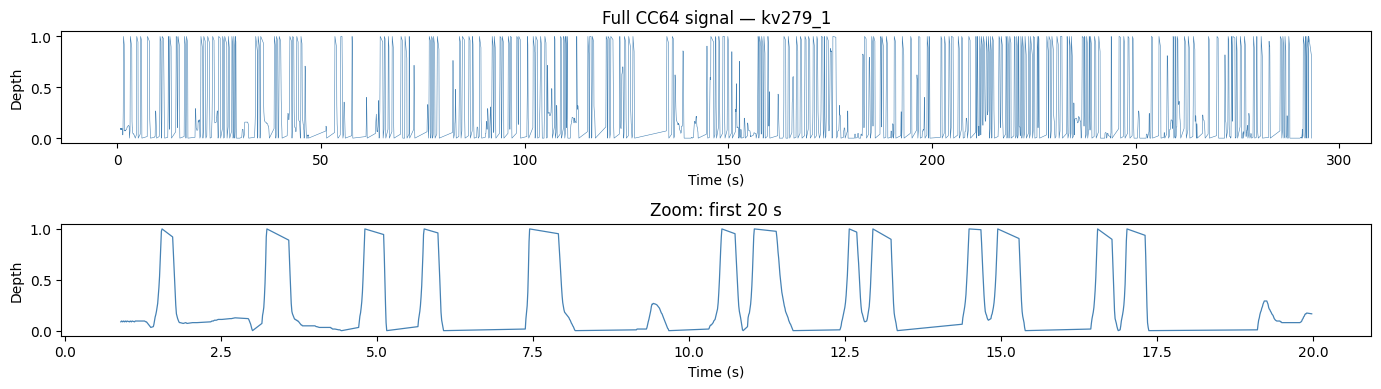

In [4]:
cc64  = sorted([c for c in pp.controls if c['number']==64], key=lambda c: c['time'])
t_raw = np.array([c['time']  for c in cc64])
v_raw = np.array([c['value'] for c in cc64]) / 127.0
print(f'CC64 messages: {len(cc64)}  |  Duration: {t_raw[-1]:.1f}s')

fig, axes = plt.subplots(2, 1, figsize=(14, 4))
axes[0].plot(t_raw, v_raw, lw=0.4, color='steelblue')
axes[0].set_title(f'Full CC64 signal — {MOVEMENT}')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Depth')
mask = t_raw < 20
axes[1].plot(t_raw[mask], v_raw[mask], lw=0.9, color='steelblue')
axes[1].set_title('Zoom: first 20 s')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Depth')
plt.tight_layout(); plt.show()

## Score–performance alignment

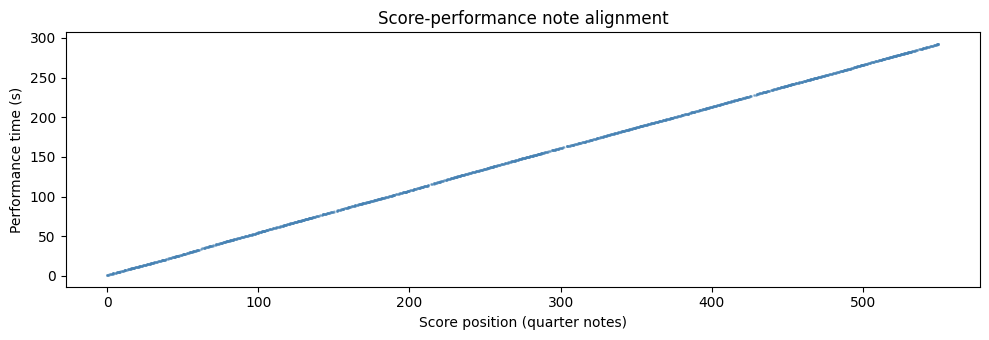

In [5]:
s_id2q = {n['id']: float(n['onset_quarter']) for n in sna}
p_id2t = {n['id']: float(n['onset_sec'])     for n in pna}
pairs = [(s_id2q[a['score_id']], p_id2t[a['performance_id']])
         for a in alignment if a['label']=='match'
         and a['score_id'] in s_id2q and a['performance_id'] in p_id2t]
qs, ts = zip(*pairs)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(qs, ts, s=1, alpha=0.3, color='steelblue')
ax.set_xlabel('Score position (quarter notes)')
ax.set_ylabel('Performance time (s)')
ax.set_title('Score-performance note alignment')
plt.tight_layout(); plt.show()

## Musicological annotations

In [6]:
df_ann = pd.read_csv(f'{DATASET}/score_parts_annotated/{MOVEMENT}_spart_annotated.csv')
print('Columns:', list(df_ann.columns))
print(f'\nHarmony (top 10):\n{df_ann["chord"].dropna().value_counts().head(10)}')
print(f'\nCadence types:\n{df_ann["cadence"][df_ann["cadence"].notna() & (df_ann["cadence"] != 0)].value_counts()}')

Columns: ['onset_beat', 'duration_beat', 'onset_quarter', 'duration_quarter', 'onset_div', 'duration_div', 'pitch', 'voice', 'id', 'xml_mn', 'mn', 'duration_qb', 'timesig', 'label', 'globalkey', 'localkey', 'chord', 'numeral', 'cadence', 'phraseend', 'chord_type']

Harmony (top 10):
chord
I      60
I6     30
V7     30
ii6    29
V      20
IV     18
IV6    14
V65    12
I64    12
V6     10
Name: count, dtype: int64

Cadence types:
cadence
PAC    17
HC      8
IAC     3
DC      2
Name: count, dtype: int64


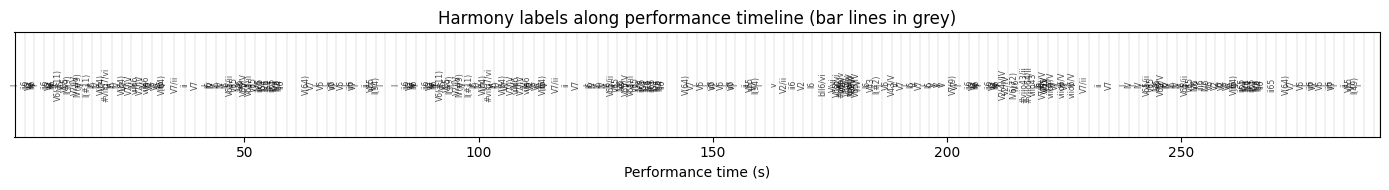

In [7]:
q2t = build_score_to_perf_map(sna, pna, alignment)
beat_qs, beat_ts = build_beat_grid(sna, q2t, beat_unit=beat_unit_from_timesig_str('4/4'))
harm = df_ann.dropna(subset=['chord']).drop_duplicates('onset_quarter')[['onset_quarter','chord']]
harm['perf_time'] = harm['onset_quarter'].apply(lambda q: float(q2t(q)))

fig, ax = plt.subplots(figsize=(14, 2))
for _, row in harm.iterrows():
    ax.text(row['perf_time'], 0.5, row['chord'],
            fontsize=5.5, rotation=90, va='center', ha='center', alpha=0.7)
for bt in beat_ts[::4]:
    ax.axvline(bt, color='grey', lw=0.3, alpha=0.5)
ax.set_xlim(beat_ts[0], beat_ts[-1]); ax.set_yticks([])
ax.set_xlabel('Performance time (s)')
ax.set_title('Harmony labels along performance timeline (bar lines in grey)')
plt.tight_layout(); plt.show()